<a href="https://colab.research.google.com/github/armandoordonez/AI-Engineering/blob/main/transformers_basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# De arquitecturas convolucionales a los Transformers

Este notebook desarrolla, en orden creciente de profundidad, los fundamentos de la arquitectura Transformer. Se parte de las limitaciones de las arquitecturas previas (redes convolucionales y recurrentes) y se construye, paso a paso, el mecanismo de autoatención hasta llegar a un bloque codificador completo, implementado únicamente con NumPy para exponer cada operación de forma explícita.

**Contenidos**

1. De CNNs/RNNs a Transformers: motivación
2. La idea de atención: un ejemplo mínimo
3. Formalización de la autoatención (Q, K, V)
4. Atención multi-cabeza
5. Codificación posicional
6. Ensamblaje de un bloque codificador
7. Síntesis comparativa


## 1. De CNNs/RNNs a Transformers: motivación

Las redes neuronales convolucionales (CNN) y las redes neuronales recurrentes (RNN) fueron, hasta 2017, las arquitecturas dominantes para el procesamiento de secuencias. Ambas presentan limitaciones estructurales relevantes para el modelado de lenguaje.

**Redes recurrentes.** Procesan la secuencia token a token, actualizando un estado oculto en cada paso. Esto impone dos restricciones:

- *Cómputo secuencial*: el estado en el paso *t* depende del estado en *t-1*, lo que impide paralelizar el procesamiento a lo largo de la secuencia durante el entrenamiento.
- *Dependencias de largo alcance*: la información debe propagarse a través de todos los pasos intermedios, lo que provoca degradación del gradiente (vanishing/exploding gradient) y dificulta capturar relaciones entre elementos distantes.

**Redes convolucionales.** Aplican filtros con un campo receptivo local. Para relacionar dos posiciones distantes en la secuencia es necesario apilar varias capas, de modo que el número de capas necesario crece con la distancia entre los elementos que se desea relacionar.

**El mecanismo de atención** resuelve ambas limitaciones de manera simultánea: permite que cada posición de la secuencia acceda directamente a cualquier otra posición en una sola operación, sin importar la distancia entre ellas, y dicha operación puede calcularse en paralelo para todas las posiciones a la vez.

La siguiente celda ilustra, de forma esquemática, la diferencia entre el patrón de conectividad de una RNN (cadena secuencial) y el de una capa de atención (conectividad completa entre todas las posiciones).

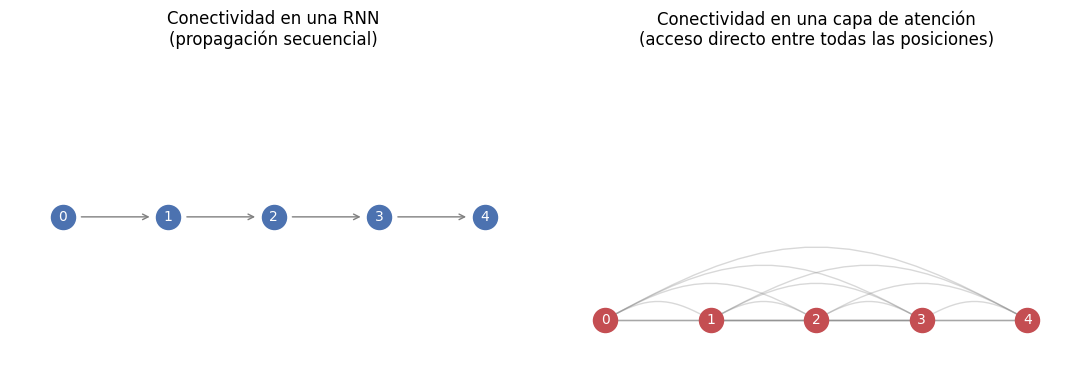

In [1]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

positions = np.arange(5)

# Patron RNN: conexiones solo entre posiciones consecutivas
ax = axes[0]
for i in positions:
    ax.scatter(i, 0, s=300, color="#4C72B0", zorder=3)
    ax.text(i, 0, str(i), ha="center", va="center", color="white", fontsize=10, zorder=4)
for i in range(len(positions) - 1):
    ax.annotate("", xy=(i + 1 - 0.15, 0), xytext=(i + 0.15, 0),
                arrowprops=dict(arrowstyle="->", color="gray"))
ax.set_title("Conectividad en una RNN\n(propagación secuencial)")
ax.set_xlim(-0.5, 4.5)
ax.set_ylim(-1, 1)
ax.axis("off")

# Patron de atencion: conexiones entre todas las posiciones
ax = axes[1]
for i in positions:
    ax.scatter(i, 0, s=300, color="#C44E52", zorder=3)
    ax.text(i, 0, str(i), ha="center", va="center", color="white", fontsize=10, zorder=4)
for i in positions:
    for j in positions:
        if i < j:
            ax.plot([i, j], [0, 0], color="gray", alpha=0.25, zorder=1,
                     linestyle="-", linewidth=1)
            # arco para visualizar todas las conexiones sin superponerlas en una linea recta
            mid = (i + j) / 2
            height = 0.15 * (j - i)
            xs = np.linspace(i, j, 20)
            ys = height * np.sin(np.pi * (xs - i) / (j - i))
            ax.plot(xs, ys, color="gray", alpha=0.3, linewidth=1, zorder=1)
ax.set_title("Conectividad en una capa de atención\n(acceso directo entre todas las posiciones)")
ax.set_xlim(-0.5, 4.5)
ax.set_ylim(-0.5, 2.2)
ax.axis("off")

plt.tight_layout()
plt.show()

En la RNN, la posición 4 solo puede recibir información de la posición 0 luego de atravesar cuatro pasos de propagación. En la capa de atención, la posición 4 accede directamente a la posición 0 en un único paso de cómputo. Esta propiedad es la base conceptual de la arquitectura Transformer, presentada en Vaswani et al. (2017).

## 2. La idea de atención: un ejemplo mínimo

Antes de introducir la formalización matemática completa, conviene examinar la idea central con un ejemplo mínimo. Considérese la oración *"el gato duerme"*, representada por tres vectores de juguete elegidos manualmente para que "gato" y "duerme" sean más similares entre sí que "el" respecto a cualquiera de los otros dos.

La atención, en su forma más simple, consiste en:

1. Calcular una medida de similitud entre cada par de vectores (producto punto).
2. Normalizar esas similitudes con una función softmax, de modo que para cada palabra se obtenga una distribución de pesos que suma 1.
3. Usar esos pesos para construir una nueva representación de cada palabra como combinación ponderada de todas las palabras de la secuencia (incluida ella misma).

In [2]:
import numpy as np

tokens = ["el", "gato", "duerme"]

# Vectores de juguete de dimension 4, elegidos para ilustrar similitud semantica
embeddings = np.array([
    [1.0, 0.0, 0.0, 0.1],   # "el"
    [0.9, 0.8, 0.1, 0.0],   # "gato"
    [0.1, 0.7, 0.9, 0.2],   # "duerme"
])

def softmax(x, axis=-1):
    x = x - np.max(x, axis=axis, keepdims=True)
    e = np.exp(x)
    return e / np.sum(e, axis=axis, keepdims=True)

scores = embeddings @ embeddings.T
weights = softmax(scores)
output = weights @ embeddings

print("Puntajes de similitud (producto punto):")
print(np.round(scores, 2))
print()
print("Pesos de atención (tras softmax), cada fila suma 1:")
print(np.round(weights, 2))

Puntajes de similitud (producto punto):
[[1.01 0.9  0.12]
 [0.9  1.46 0.74]
 [0.12 0.74 1.35]]

Pesos de atención (tras softmax), cada fila suma 1:
[[0.43 0.39 0.18]
 [0.28 0.49 0.24]
 [0.16 0.3  0.54]]


El resultado muestra que "gato" y "duerme" se asignan pesos relativamente altos entre sí, mientras que "el" recibe menor peso desde las otras dos posiciones. La nueva representación de cada palabra (`output`) ya no depende únicamente de su propio vector, sino que incorpora información del resto de la secuencia, ponderada según relevancia.

Este ejemplo utiliza los mismos vectores como consulta, clave y valor. La sección siguiente introduce la distinción entre estos tres roles, que es la base de la autoatención tal como se emplea en los Transformers.

## 3. Formalización de la autoatención (Q, K, V)

En la autoatención (self-attention), cada vector de entrada se proyecta en tres espacios distintos mediante matrices de pesos aprendidas:

- **Query (Q)**: representa "qué información busca" la posición actual.
- **Key (K)**: representa "qué información ofrece" cada posición para ser comparada con las consultas.
- **Value (V)**: representa el contenido real que se propaga si la posición resulta relevante.

Formalmente, dada una matriz de entrada $X \in \mathbb{R}^{n \times d}$ (donde $n$ es la longitud de la secuencia y $d$ la dimensión del embedding):

$$Q = XW_Q, \quad K = XW_K, \quad V = XW_V$$

La salida de la atención se calcula como:

$$\text{Attention}(Q,K,V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

El factor $\sqrt{d_k}$ escala los puntajes antes del softmax. Sin este escalamiento, para valores grandes de $d_k$ los productos punto tienden a crecer en magnitud, lo que empuja al softmax hacia regiones de gradiente casi nulo y dificulta el entrenamiento.

A continuación se implementa este cálculo completo con matrices de proyección aleatorias, sobre una secuencia de longitud 4 y dimensión de embedding 8.

In [3]:
import numpy as np

np.random.seed(0)

def softmax(x, axis=-1):
    x = x - np.max(x, axis=axis, keepdims=True)
    e = np.exp(x)
    return e / np.sum(e, axis=axis, keepdims=True)

seq_len, d_model = 4, 8

X = np.random.randn(seq_len, d_model)

W_Q = np.random.randn(d_model, d_model) * 0.1
W_K = np.random.randn(d_model, d_model) * 0.1
W_V = np.random.randn(d_model, d_model) * 0.1

Q = X @ W_Q
K = X @ W_K
V = X @ W_V

d_k = Q.shape[-1]
scores = (Q @ K.T) / np.sqrt(d_k)
weights = softmax(scores)
output = weights @ V

print("Dimensiones: Q", Q.shape, "K", K.shape, "V", V.shape)
print()
print("Matriz de pesos de atención:")
print(np.round(weights, 3))
print()
print("Dimensión de la salida:", output.shape)

Dimensiones: Q (4, 8) K (4, 8) V (4, 8)

Matriz de pesos de atención:
[[0.237 0.266 0.254 0.243]
 [0.246 0.252 0.249 0.253]
 [0.227 0.252 0.274 0.247]
 [0.225 0.27  0.263 0.242]]

Dimensión de la salida: (4, 8)


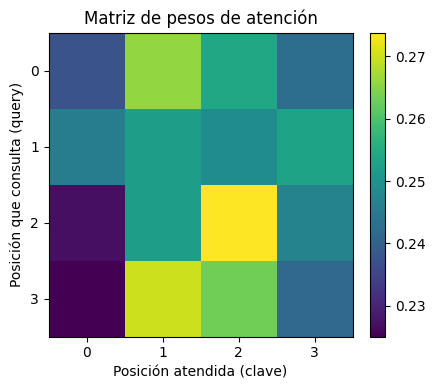

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(weights, cmap="viridis")
ax.set_xticks(range(seq_len))
ax.set_yticks(range(seq_len))
ax.set_xlabel("Posición atendida (clave)")
ax.set_ylabel("Posición que consulta (query)")
ax.set_title("Matriz de pesos de atención")
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

Cada fila de la matriz de pesos corresponde a una posición que "consulta" y cada columna a una posición que es "atendida". Puesto que cada fila proviene de un softmax, sus valores suman 1: la salida en cada posición es un promedio ponderado de los valores (V) de toda la secuencia, con pesos determinados por la compatibilidad entre la consulta de esa posición y las claves de todas las demás.

## 4. Atención multi-cabeza

Una sola operación de atención produce un único patrón de ponderación por posición. En la práctica, es útil que el modelo capture simultáneamente distintos tipos de relación entre tokens (por ejemplo, relaciones sintácticas y relaciones semánticas). Para ello, la atención multi-cabeza divide las proyecciones Q, K y V en $h$ subespacios de menor dimensión, calcula la atención de manera independiente en cada uno, y concatena los resultados.

Formalmente, con $h$ cabezas y $d_{head} = d_{model}/h$:

$$\text{head}_i = \text{Attention}(XW_Q^{(i)}, XW_K^{(i)}, XW_V^{(i)})$$

$$\text{MultiHead}(X) = \text{Concat}(\text{head}_1, \dots, \text{head}_h)W_O$$

La siguiente implementación reutiliza las proyecciones Q, K, V ya calculadas, dividiéndolas en dos cabezas.

In [5]:
num_heads = 2
d_head = d_model // num_heads

def split_heads(M, num_heads, d_head):
    seq_len = M.shape[0]
    return M.reshape(seq_len, num_heads, d_head).transpose(1, 0, 2)

Qh = split_heads(Q, num_heads, d_head)
Kh = split_heads(K, num_heads, d_head)
Vh = split_heads(V, num_heads, d_head)

head_outputs = []
head_weights = []
for h in range(num_heads):
    scores_h = (Qh[h] @ Kh[h].T) / np.sqrt(d_head)
    weights_h = softmax(scores_h)
    out_h = weights_h @ Vh[h]
    head_outputs.append(out_h)
    head_weights.append(weights_h)

multihead_output = np.concatenate(head_outputs, axis=-1)

print("Dimensión de cada cabeza:", head_outputs[0].shape)
print("Dimensión tras concatenar las", num_heads, "cabezas:", multihead_output.shape)

Dimensión de cada cabeza: (4, 4)
Dimensión tras concatenar las 2 cabezas: (4, 8)


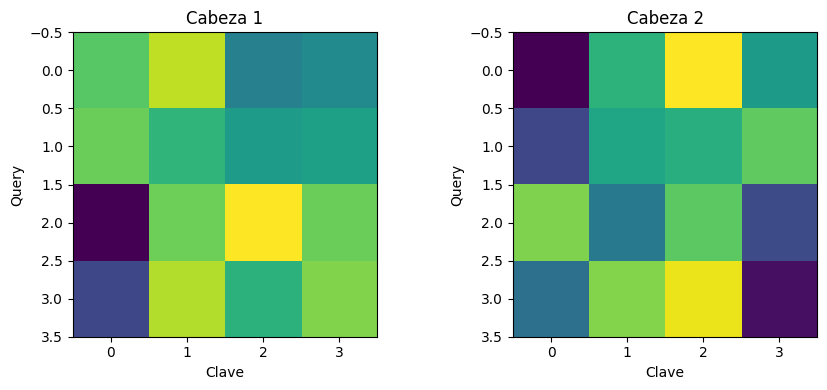

In [6]:
fig, axes = plt.subplots(1, num_heads, figsize=(9, 4))
for h in range(num_heads):
    im = axes[h].imshow(head_weights[h], cmap="viridis")
    axes[h].set_title(f"Cabeza {h+1}")
    axes[h].set_xlabel("Clave")
    axes[h].set_ylabel("Query")
plt.tight_layout()
plt.show()

Cada cabeza opera sobre una proyección distinta del mismo vector de entrada y, por lo tanto, puede converger durante el entrenamiento hacia patrones de atención diferentes. En un Transformer entrenado a escala, es común observar cabezas especializadas en relaciones sintácticas locales (por ejemplo, sujeto-verbo) y otras en relaciones semánticas de mayor alcance.

## 5. Codificación posicional

La operación de atención descrita hasta ahora es invariante ante permutaciones: si se reordenan las filas de $X$, la salida se reordena de la misma manera pero los valores no cambian, dado que no hay ninguna noción de orden en el cálculo. A diferencia de las RNN (donde el orden está implícito en el procesamiento secuencial) o las CNN (donde el orden está implícito en la posición relativa de los filtros), el Transformer necesita que la información de posición se incorpore explícitamente en la representación de entrada.

Vaswani et al. (2017) proponen una codificación posicional basada en funciones seno y coseno de distinta frecuencia:

$$PE_{(pos,\,2i)} = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

$$PE_{(pos,\,2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

donde $pos$ es la posición en la secuencia e $i$ el índice de la dimensión. Estos vectores se suman directamente a los embeddings de entrada antes de la primera capa de atención.

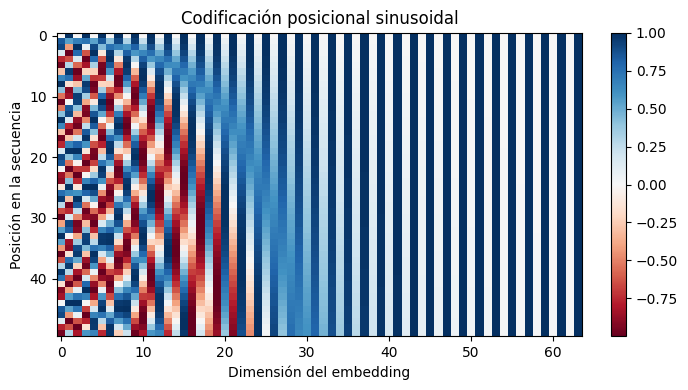

Dimensión de la entrada con codificación posicional sumada: (4, 8)


In [7]:
def positional_encoding(seq_len, d_model):
    pos = np.arange(seq_len)[:, None]
    i = np.arange(d_model)[None, :]
    angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
    angle_rads = pos * angle_rates
    pe = np.zeros((seq_len, d_model))
    pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
    pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
    return pe

seq_len_demo, d_model_demo = 50, 64
pe = positional_encoding(seq_len_demo, d_model_demo)

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(pe, cmap="RdBu", aspect="auto")
ax.set_xlabel("Dimensión del embedding")
ax.set_ylabel("Posición en la secuencia")
ax.set_title("Codificación posicional sinusoidal")
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

X_with_position = X + positional_encoding(seq_len, d_model)
print("Dimensión de la entrada con codificación posicional sumada:", X_with_position.shape)

Cada dimensión de la codificación posicional oscila con una frecuencia distinta, de modo que cada posición de la secuencia queda asociada a un patrón único a lo largo de las $d_{model}$ dimensiones. Una propiedad relevante de esta construcción es que la codificación de una posición puede expresarse como una función lineal de la codificación de otra posición cercana, lo que en principio facilita que el modelo aprenda a atender por posición relativa. En arquitecturas más recientes se emplean variantes como RoPE (Rotary Position Embedding), que incorporan la posición directamente en el cálculo de Q y K en lugar de sumarla a la entrada.

## 6. Ensamblaje de un bloque codificador

Un bloque codificador (encoder layer) combina la atención multi-cabeza con una red feed-forward posicional, intercaladas con conexiones residuales y normalización de capa (layer normalization). La estructura, siguiendo la variante *post-norm* original, es:

$$Z = \text{LayerNorm}(X + \text{MultiHead}(X))$$

$$\text{FFN}(Z) = \max(0,\, ZW_1 + b_1)W_2 + b_2$$

$$\text{Salida} = \text{LayerNorm}(Z + \text{FFN}(Z))$$

Las conexiones residuales facilitan la propagación del gradiente en redes profundas, y la normalización de capa estabiliza la distribución de las activaciones entre capas. La red feed-forward, aplicada de manera idéntica e independiente a cada posición, introduce una transformación no lineal adicional sobre la representación generada por la atención.

A continuación se ensamblan estos componentes utilizando los resultados de las secciones anteriores.

In [8]:
def layer_norm(x, eps=1e-6):
    mean = x.mean(axis=-1, keepdims=True)
    var = x.var(axis=-1, keepdims=True)
    return (x - mean) / np.sqrt(var + eps)

def relu(x):
    return np.maximum(0, x)

d_ff = d_model * 4
W1 = np.random.randn(d_model, d_ff) * 0.1
b1 = np.zeros(d_ff)
W2 = np.random.randn(d_ff, d_model) * 0.1
b2 = np.zeros(d_model)

# Paso 1: atencion + conexion residual + normalizacion
attn_out = output  # calculado en la Sección 3
Z = layer_norm(X + attn_out)

# Paso 2: red feed-forward + conexion residual + normalizacion
ffn_hidden = relu(Z @ W1 + b1)
ffn_out = ffn_hidden @ W2 + b2
encoder_output = layer_norm(Z + ffn_out)

print("Dimensión de entrada al bloque:", X.shape)
print("Dimensión de salida del bloque codificador:", encoder_output.shape)
print()
print("Salida del bloque codificador (primeras 3 dimensiones de cada posición):")
print(np.round(encoder_output[:, :3], 3))

Dimensión de entrada al bloque: (4, 8)
Dimensión de salida del bloque codificador: (4, 8)

Salida del bloque codificador (primeras 3 dimensiones de cada posición):
[[ 0.909 -0.317  0.286]
 [-1.239  0.226 -0.278]
 [ 1.225 -0.11   0.435]
 [ 1.555 -1.86  -0.217]]


La dimensión de salida del bloque coincide con la dimensión de entrada ($d_{model}$), lo que permite apilar múltiples bloques codificadores de manera consecutiva. Un Transformer completo consiste, en su forma más simple, en $N$ bloques de este tipo aplicados en secuencia, precedidos por la suma de los embeddings de entrada con la codificación posicional.